In [2]:
from veripulse.pulse import PulseConfig, PulseResult, lam_from_ratio, ratio_from_lam
import re
import json
import numpy as np
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d
import matplotlib.ticker as ticker

%matplotlib inline

In [3]:
# data folder
data_dir_dummyyes = Path.cwd().parent/"data/dummyyes"
data_dir_dummyless = Path.cwd().parent/"data/dummyless"


# file naming pattern
_PATTERN = re.compile(
    r"^(?P<method>[^_]+)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-(?P<identification>.+)\.json$"
)

# GRAPE_AVG:  GRAPE_AVG_pN_detX.XX_errX.XX-lamX.X-ID.json
_PATTERN_AVG = re.compile(
    r"^(?P<method>GRAPE_AVG)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-lam(?P<lam>[\d.]+)-(?P<identification>.+)\.json$"
)

# parsers

def parse_filename(path: Path) -> Optional[dict]:
    # Try GRAPE_AVG first (more specific), then fall back to generic
    m = _PATTERN_AVG.match(path.name) or _PATTERN.match(path.name)
    if not m:
        return None
    d = {
        "path":           path,
        "method":         m.group("method"),
        "num_tslots":     int(m.group("num_tslots")),
        "detuning":       float(m.group("detuning")),
        "drive_error":    float(m.group("drive_error")),
        "identification": m.group("identification"),
        "lam":            float(m.group("lam")) if "lam" in m.groupdict() and m.group("lam") is not None else None,
    }
    return d

def collect_files(
    directory: str | Path,
    method: Optional[str] = None,
    num_tslots: Optional[int] = None,
    detuning: Optional[float] = None,
    drive_error: Optional[float] = None,
    identification: Optional[str] = None,
    lam: Optional[float] = None,
    load: bool = False,
) -> list[dict]:
    results = []
    for path in sorted(Path(directory).glob("*.json")):
        meta = parse_filename(path)
        if meta is None:
            continue

        if method        is not None and meta["method"]      != method:                               continue
        if num_tslots    is not None and meta["num_tslots"]  != num_tslots:                           continue
        if detuning      is not None and f"{meta['detuning']:.2f}"    != f"{detuning:.2f}":           continue
        if drive_error   is not None and f"{meta['drive_error']:.2f}" != f"{drive_error:.2f}":        continue
        if identification is not None and meta["identification"] != str(identification):               continue
        if lam           is not None and (meta["lam"] is None or f"{meta['lam']:.3f}" != f"{lam:.3f}"): continue

        if load:
            with open(path) as f:
                meta["data"] = json.load(f)

        results.append(meta)

    return results


def cost_rate_grape_avg(lam, n=1):
    """
    intuitively identify the sensitivity/rate for s.i vs fidelity in grape_avg
        f = 0.5n^-3 fHS + lam fSI
        n=1, GRAPE
        n=8,10, for GRAPE AVG
    """
    c_hs = 0.5/(n**3)
    c_si = lam
    ratio = c_si / c_hs
    print("f_SI is {:.6f}x more influential than f_HS in the cost".format(ratio))




def summary_lambda(slot, data_dir, lams):
    summary = dict()
    for lam in lams: 
        summary[lam] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': [], 'eval':[], 'config':[]}
        runs = collect_files(data_dir, method='GRAPE_AVG', num_tslots=slot, lam=lam)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[lam]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[lam]['cost'].append(np.mean(res.err_hs_list)) 
            summary[lam]['si_lb'].append(res.si_lb)
            summary[lam]['si'].append(res.si)
            summary[lam]['diff'].append(res.si_lb - res.si)
            summary[lam]['config'].append(res.config)
            summary[lam]['eval'].append(res.fid_compute_list)
    return summary

# Eval counting until convergence

In [4]:
def summary_byslot(method, slots, data_dir, lam=None):
    summary = dict()
    for slot in slots: 
        summary[slot] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': [], 'eval':[], 'config':[]}
        if lam is not None:
            runs = collect_files(data_dir, method=method, num_tslots=slot, lam=lam)
        else:
            runs = collect_files(data_dir, method=method, num_tslots=slot)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[slot]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[slot]['cost'].append(np.mean(res.err_hs_list)) 
            summary[slot]['si_lb'].append(res.si_lb)
            summary[slot]['si'].append(res.si)
            summary[slot]['diff'].append(res.si_lb - res.si)
            summary[slot]['config'].append(res.config)
            if method != 'GRAPE_AVG':
                summary[slot]['eval'].append(sum(res.fid_compute_list))
            else:
                summary[slot]['eval'].append(res.fid_compute_list)
    return summary

In [5]:
_QUANTITY_LABEL = {
    'si':   'Secrecy Index (SI)',
    'eval': 'Function evaluations',
    'fid':  'Infidelity  1 − F',
    'time': 'Wall time (s)',
}


def plot_summary_property(
    summaries: dict,
    quantity: str,
    log_y: bool = False,
    ylabel: str | None = None,
    title:  str | None = None,
):
    """
    Publication-quality line plot of a summary quantity vs tslots.

    Parameters
    ----------
    summaries : dict  {label: {tslots: {quantity: [values], 'config': [...]}}}
    quantity  : str   key inside each tslots dict
    log_y     : bool  logarithmic y-axis
    ylabel    : str   override y-axis label
    title     : str   override plot title
    """
    # ── extract evo_time from stored configs ──────────────────────────────────
    evo_times = {}
    for summary in summaries.values():
        for slot, data in summary.items():
            if slot not in evo_times and data.get('config'):
                cfg = data['config'][0]   # first run's config is enough
                evo_times[slot] = cfg.evo_time
    plt.rcParams.update({
        'font.family':       'sans-serif',
        'font.size':         9,
        'axes.labelsize':    10,
        'axes.titlesize':    11,
        'legend.fontsize':   8.5,
        'xtick.labelsize':   8.5,
        'ytick.labelsize':   8.5,
        'axes.linewidth':    0.8,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
        'lines.linewidth':   1.8,
        'figure.dpi':        150,
    })

    fig, ax = plt.subplots(figsize=(5.5, 3.2), constrained_layout=True)

    for key, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))
        means, stds = [], []
        for x in xs:
            vals = np.array(summary[x][quantity], dtype=float)
            means.append(vals.mean())
            stds.append(vals.std())
        means = np.array(means)
        stds  = np.array(stds)

        line, = ax.plot(xs, means, marker='o', markersize=4,
                        markeredgewidth=0.5, markeredgecolor='white',
                        label=key, zorder=3)
        ax.fill_between(xs, means - stds, means + stds,
                        alpha=0.15, color=line.get_color(),
                        linewidth=0, zorder=2)

    # ── y axis ────────────────────────────────────────────────────────────────
    if log_y:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

    ax.set_ylabel(ylabel or _QUANTITY_LABEL.get(quantity, quantity))
    ax.set_title(title or _QUANTITY_LABEL.get(quantity, quantity),
                 fontweight='semibold', pad=6)

    # ── x axis: tslots + optional ns line below ───────────────────────────────
    all_xs = sorted({x for s in summaries.values() for x in s.keys()})
    ax.set_xticks(all_xs)

    if evo_times:
        xlabels = [f"{p}\n({evo_times[p]/p*1e9:.2f} ns)" if p in evo_times
                   else str(p) for p in all_xs]
        ax.set_xlabel("tslots(pulse resolution)")
    else:
        xlabels = [str(p) for p in all_xs]
        ax.set_xlabel("tslots")

    ax.set_xticklabels(xlabels, fontsize=8)

    # ── grid + frame ──────────────────────────────────────────────────────────
    ax.yaxis.grid(True, which='major', linestyle=':', linewidth=0.5,
                  color='#AAAAAA', alpha=0.7, zorder=0)
    ax.yaxis.grid(True, which='minor', linestyle=':', linewidth=0.3,
                  color='#CCCCCC', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    # keep all four spines (full frame)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    ax.legend(frameon=True, framealpha=0.92, edgecolor='#BBBBBB',
              fancybox=False, handlelength=2.0, borderpad=0.6,
              loc='best')

    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

/tmp/ipykernel_3019739/3736887152.py:56: RuntimeWarning: Mean of empty slice
  means.append(vals.mean())
/users/home/gustiani/VeriPulse/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/users/home/gustiani/VeriPulse/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/users/home/gustiani/VeriPulse/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/users/home/gustiani/VeriPulse/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


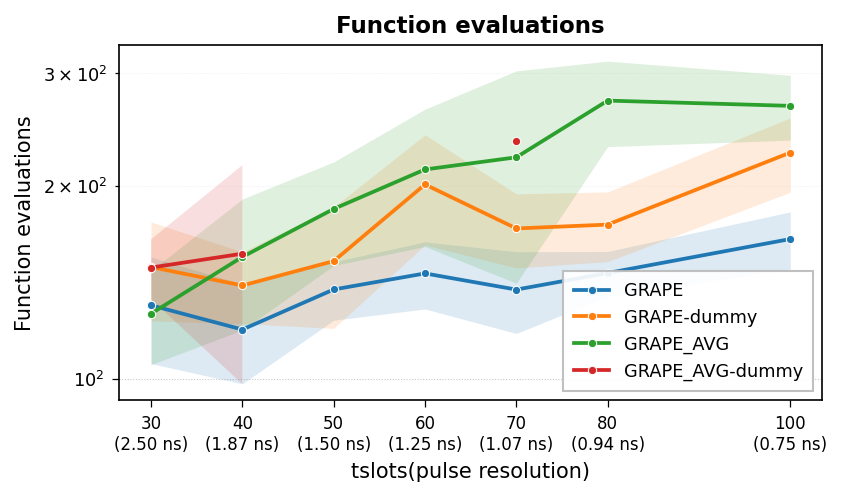

In [26]:
slots = [30, 40, 50, 60, 70, 80, 100]
summaries = dict()
#summaries['CRAB'] = summary_byslot('CRAB', slots, data_dir_dummyless)
#summaries['CRAB-dummy'] = summary_byslot('CRAB', slots, data_dir_dummyyes)
summaries['GRAPE'] = summary_byslot("GRAPE", slots, data_dir_dummyless)
summaries['GRAPE-dummy'] = summary_byslot("GRAPE", slots, data_dir_dummyyes)
summaries['GRAPE_AVG'] = summary_byslot('GRAPE_AVG', slots, data_dir_dummyless)
summaries['GRAPE_AVG-dummy'] = summary_byslot('GRAPE_AVG', slots, data_dir_dummyyes)
plot_summary_property(summaries = summaries, quantity='eval', log_y=True)

# Heatmap of lambda and tslots

In [7]:
def plot_grape_heatmap(
    data_dir,
    lambdas,
    tslots_list,
    show='si',
    show_grape=True,
    show_crab=True,
):
    """
    Single unified heatmap.

    Top block  — GRAPE_AVG, one row per λ.
    ══════════ thick divider ══════════════
    Bottom     — optional GRAPE / CRAB reference rows.

    X-axis always shows both:   tslots  (xx ns)

    Colour scale anchored to GRAPE_AVG; reference rows that exceed it
    saturate to yellow (clip=True).
    """
    n_lam    = len(lambdas)
    n_tslots = len(tslots_list)
    label    = "Mean SI" if show == 'si' else "Mean 1-F"

    def _metric(res):
        return res.si if show == 'si' else np.mean(res.err_ul_list)

    # ── collect GRAPE_AVG ─────────────────────────────────────────────────────
    mean_avg = np.full((n_lam, n_tslots), np.nan)
    std_avg  = np.full((n_lam, n_tslots), np.nan)
    evo_times = {}

    for i, lam in enumerate(lambdas):
        for j, tslots in enumerate(tslots_list):
            metas = collect_files(directory=data_dir, method='GRAPE_AVG',
                                  num_tslots=tslots, lam=lam,
                                  detuning=0.0, drive_error=0.0)
            vals = []
            for m in metas:
                res = PulseResult.load(m['path'])
                vals.append(_metric(res))
                if tslots not in evo_times:
                    evo_times[tslots] = res.config.evo_time
            if vals:
                mean_avg[i, j] = np.mean(vals)
                std_avg[i, j]  = np.std(vals)

    # ── collect GRAPE ─────────────────────────────────────────────────────────
    mean_grape = np.full(n_tslots, np.nan)
    std_grape  = np.full(n_tslots, np.nan)
    if show_grape:
        for j, tslots in enumerate(tslots_list):
            metas = collect_files(directory=data_dir, method='GRAPE',
                                  num_tslots=tslots,
                                  detuning=0.0, drive_error=0.0)
            vals = []
            for m in metas:
                res = PulseResult.load(m['path'])
                vals.append(_metric(res))
                if tslots not in evo_times:
                    evo_times[tslots] = res.config.evo_time
            if vals:
                mean_grape[j] = np.mean(vals)
                std_grape[j]  = np.std(vals)

    # ── collect CRAB ──────────────────────────────────────────────────────────
    mean_crab = np.full(n_tslots, np.nan)
    std_crab  = np.full(n_tslots, np.nan)
    if show_crab:
        for j, tslots in enumerate(tslots_list):
            metas = collect_files(directory=data_dir, method='CRAB',
                                  num_tslots=tslots,
                                  detuning=0.0, drive_error=0.0)
            vals = []
            for m in metas:
                res = PulseResult.load(m['path'])
                vals.append(_metric(res))
                if tslots not in evo_times:
                    evo_times[tslots] = res.config.evo_time
            if vals:
                mean_crab[j] = np.mean(vals)
                std_crab[j]  = np.std(vals)

    # ── build unified matrix ──────────────────────────────────────────────────
    ref_rows = []
    if show_grape:
        ref_rows.append((mean_grape, std_grape, 'GRAPE'))
    if show_crab:
        ref_rows.append((mean_crab, std_crab, 'CRAB'))

    n_ref  = len(ref_rows)
    n_rows = n_lam + n_ref

    data_matrix = np.full((n_rows, n_tslots), np.nan)
    std_matrix  = np.full((n_rows, n_tslots), np.nan)
    data_matrix[:n_lam, :] = mean_avg
    std_matrix[:n_lam, :]  = std_avg
    for k, (d, s, _) in enumerate(ref_rows):
        data_matrix[n_lam + k, :] = d
        std_matrix[n_lam + k, :]  = s

    # ── colour scale anchored to GRAPE_AVG ───────────────────────────────────
    flat = mean_avg.ravel()
    flat = flat[~np.isnan(flat) & (flat > 0)]
    vmin, vmax = flat.min(), flat.max()
    norm = LogNorm(vmin=vmin, vmax=vmax, clip=True)
    cmap = plt.get_cmap("viridis")

    # ── x tick labels: "N\n(xx ns)" ──────────────────────────────────────────
    xlabels = []
    for ts in tslots_list:
        ns = evo_times.get(ts, 0) / ts * 1e9
        xlabels.append(f"{ts}\n({ns:.0f} ns)")

    # ── y labels ─────────────────────────────────────────────────────────────
    ylabels = [f"{l:.2g}" for l in lambdas] + [r[2] for r in ref_rows]

    # ── figure — no tight_layout, use constrained_layout ─────────────────────
    W = max(8, n_tslots * 1.6 + 1.5)
    H = max(4, n_rows * 1.1 + 1.5)
    fig, (ax, ax_cbar) = plt.subplots(
        1, 2,
        figsize=(W, H),
        gridspec_kw={"width_ratios": [n_tslots, 0.4], "wspace": 0.05},
        constrained_layout=True,
    )

    # ── draw ──────────────────────────────────────────────────────────────────
    im = ax.imshow(data_matrix, aspect="auto", cmap=cmap, norm=norm)

    log_min = np.log(vmin)
    log_max = np.log(vmax)

    for i in range(n_rows):
        for j in range(n_tslots):
            val, std = data_matrix[i, j], std_matrix[i, j]
            if np.isnan(val):
                ax.text(j, i, "N/A", ha="center", va="center",
                        color="gray", fontsize=9)
            else:
                log_v = np.clip(np.log(val), log_min, log_max)
                nv    = (log_v - log_min) / (log_max - log_min + 1e-12)
                c     = "white" if nv < 0.6 else "black"
                ax.text(j, i, f"{val:.4f}\n±{std:.4f}",
                        ha="center", va="center", color=c, fontsize=9)

    # ── divider + "reference" label ───────────────────────────────────────────
    if n_ref > 0:
        ax.axhline(n_lam - 0.5, color='white', linewidth=4, zorder=5)
        # simple text label to the left of the reference block, no brackets
        #ax.text(-0.5, n_lam + (n_ref - 1) / 2, 'ref',ha='right', va='center', fontsize=8, color='#555555',fontstyle='italic', clip_on=False)

    # ── axes ──────────────────────────────────────────────────────────────────
    ax.set_xticks(np.arange(n_tslots))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_xlabel("tslots  (pulse resolution)")
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(ylabels)
    ax.set_ylabel("λ")
    ax.set_title(f"Pulse Optimisation — {label}", fontweight="bold", pad=8)

    fig.colorbar(im, cax=ax_cbar, label=label)
    plt.show()

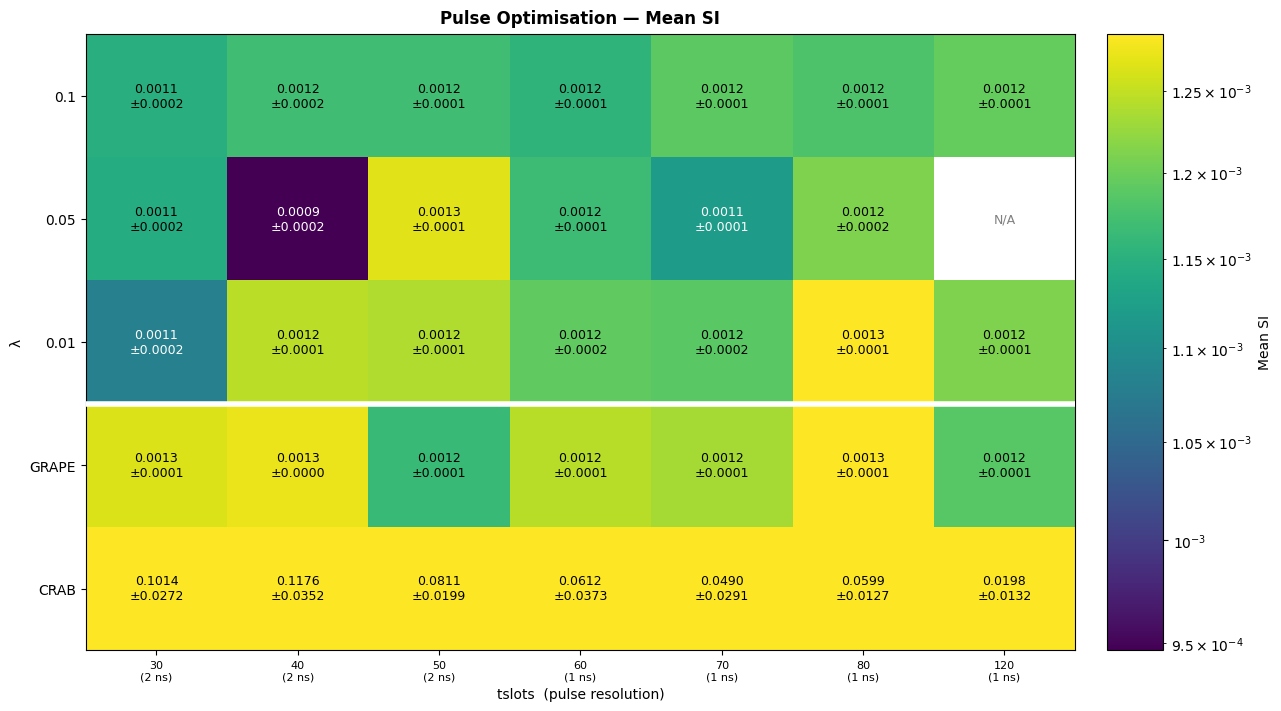

In [8]:
lambdas = [0.1, 0.05, 0.01]
tslots_list = [30,40,50,60,70,80,120]
plot_grape_heatmap(data_dir_dummyless, lambdas, tslots_list, show_grape=True, show_crab=True)

In [ ]:
lambdas = [0.1, 0.05, 0.01]
tslots_list = [30,40,50,60,70,80,120]
plot_grape_heatmap(data_dir_dummyless, lambdas, tslots_list, show_grape=True, show_crab=True)

# Complete lambdas, slot 40 

In [9]:
def plot_lambda_scan(
    data_dir,
    lambdas,
    tslots,
    si_case="min",
    log_y=False,
    separate_si=False,
    ref_methods=None,
    n_states=8,
    detuning=0.0,
    drive_error=0.0,
):
    """
    For a fixed tslots, show err_ul spread and SI across lambdas.
    si_case can be 'min', 'max', or ['min', 'max'] to show both side by side.

    Parameters
    ----------
    data_dir : str
    lambdas : list
    tslots : int
    si_case : str or list of str
        'min', 'max', or ['min', 'max'] to show both.
    log_y : bool
    separate_si : bool
    ref_methods : list of str, optional
    """
    if ref_methods is None:
        ref_methods = []
    if isinstance(si_case, str):
        si_cases = [si_case]
    else:
        si_cases = list(si_case)

    n_cases = len(si_cases)
    CASE_COLORS = {'min': 'steelblue', 'max': 'coral'}
    has_refs = len(ref_methods) > 0
    n_refs = len(ref_methods)

    if separate_si:
        if has_refs:
            fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex='col',
                                      gridspec_kw={
                                          'height_ratios': [1, 1],
                                          'width_ratios': [n_refs, len(lambdas)],
                                          'hspace': 0.05, 'wspace': 0.05,
                                      })
            ax_ref, ax_main = axes[0, 0], axes[0, 1]
            ax_ref_si, ax_main_si = axes[1, 0], axes[1, 1]
            ax_main.sharey(ax_ref)
            ax_main_si.sharey(ax_ref_si)
            ax_main.tick_params(labelleft=False)
            ax_main_si.tick_params(labelleft=False)
        else:
            fig, (ax_main, ax_main_si) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                                        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})
            ax_ref = ax_ref_si = None
    else:
        if has_refs:
            fig, (ax_ref, ax_main) = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                                                    gridspec_kw={'width_ratios': [n_refs, len(lambdas)], 'wspace': 0.05})
            ax_main.tick_params(labelleft=False)
            ax_ref_si = ax_ref.twinx()
            ax_main_si = ax_main.twinx()
            ax_ref_si.tick_params(labelright=False)
        else:
            fig, ax_main = plt.subplots(figsize=(10, 5))
            ax_main_si = ax_main.twinx()
            ax_ref = ax_ref_si = None

    box_width = 0.35 if n_cases > 1 else 0.5

    def _get_extreme(results, case):
        si_vals = np.array([res.si for res in results])
        best_idx = np.argmin(si_vals) if case == "min" else np.argmax(si_vals)
        err_ul = np.array(results[best_idx].err_ul_list, dtype=float)
        return err_ul, si_vals[best_idx]

    def _plot_group(ax_fid, ax_si, center_positions, labels, load_fn):
        """Plot boxes for all cases at each position."""
        for case_idx, case in enumerate(si_cases):
            c = CASE_COLORS.get(case, 'gray')
            offset = (case_idx - (n_cases - 1) / 2) * box_width
            case_positions = []
            case_si = []

            for i, (pos, label) in enumerate(zip(center_positions, labels)):
                results = load_fn(i)
                if not results:
                    continue
                err_ul, si_val = _get_extreme(results, case)
                if len(err_ul) == 0:
                    continue

                p = pos + offset
                case_positions.append(p)
                case_si.append(si_val)

                ax_fid.boxplot(
                    [err_ul],
                    positions=[p],
                    widths=box_width * 0.85,
                    patch_artist=True,
                    manage_ticks=False,
                    whis=(0, 100),
                    showfliers=False,
                    boxprops    =dict(facecolor=c, color=c, alpha=0.4, linewidth=1.5),
                    medianprops =dict(color='white', linewidth=2.5, solid_capstyle='round'),
                    whiskerprops=dict(color=c, linewidth=1.8, linestyle='-'),
                    capprops    =dict(color=c, linewidth=2.5),
                )
                jitter = np.random.normal(0, 0.03, size=len(err_ul))
                ax_fid.scatter(p + jitter, err_ul, color=c, s=15, zorder=5, alpha=0.6)

            if case_positions:
                # Plot SI at the same positions as the boxes
                mk = 'v' if case == 'min' else '^'
                ax_si.plot(case_positions, case_si, lw=2, ls='--', color=c, marker=mk,
                           markersize=8, alpha=0.85, zorder=10, label=f"{case} SI")

        bottom_ax = ax_si if separate_si else ax_fid
        bottom_ax.set_xticks(center_positions)
        bottom_ax.set_xticklabels(labels, rotation=30, ha='right')

    # ── Reference methods ─────────────────────────────────────────────────────
    if has_refs:
        ref_results_cache = {}
        for r_idx, ref_method in enumerate(ref_methods):
            runs = collect_files(data_dir, method=ref_method, num_tslots=tslots,
                                detuning=detuning, drive_error=drive_error)
            if runs:
                ref_results_cache[r_idx] = [PulseResult.load(r['path']) for r in runs]

        ref_positions = list(range(n_refs))
        ref_labels = ref_methods

        def load_ref(i):
            return ref_results_cache.get(i, [])

        _plot_group(ax_ref, ax_ref_si, ref_positions, ref_labels, load_ref)

    # ── GRAPE_AVG lambdas ─────────────────────────────────────────────────────
    lam_results_cache = {}
    for l_idx, lam in enumerate(lambdas):
        runs = collect_files(data_dir, method='GRAPE_AVG', num_tslots=tslots, lam=lam,
                             detuning=detuning, drive_error=drive_error)
        if runs:
            lam_results_cache[l_idx] = [PulseResult.load(r['path']) for r in runs]

    main_positions = list(range(len(lambdas)))
    main_labels = [f"λ={lam:.2g}\nr={ratio_from_lam(lam, n=n_states):.0f}" for lam in lambdas]

    def load_lam(i):
        return lam_results_cache.get(i, [])

    _plot_group(ax_main, ax_main_si, main_positions, main_labels, load_lam)

    # ── Axes cosmetics ────────────────────────────────────────────────────────
    if not separate_si:
        ax_main_si.set_zorder(ax_main.get_zorder() + 1)
        ax_main.patch.set_visible(False)
        if has_refs:
            ax_ref_si.set_zorder(ax_ref.get_zorder() + 1)
            ax_ref.patch.set_visible(False)

    for a in [ax_main, ax_ref, ax_main_si, ax_ref_si]:
        if a is not None:
            if log_y:
                a.set_yscale('log')
            a.grid(True, axis='y', linewidth=0.3, alpha=0.7)

    # Set SI y-axis lower limit
    if ax_main_si is not None:
        ax_main_si.set_ylim(bottom=3e-4)
    if ax_ref_si is not None:
        ax_ref_si.set_ylim(bottom=3e-4)

    if has_refs:
        ax_ref.set_ylabel("1-F")
        if separate_si:
            ax_ref_si.set_ylabel("SI")
            ax_ref_si.set_xlabel("Method")
            ax_main_si.set_xlabel("λ")
        else:
            ax_ref.set_xlabel("Method")
            ax_main.set_xlabel("λ")
            ax_main_si.set_ylabel("SI")
    else:
        ax_main.set_ylabel("1-F")
        if separate_si:
            ax_main_si.set_ylabel("SI")
            ax_main_si.set_xlabel("λ")
        else:
            ax_main.set_xlabel("λ")
            ax_main_si.set_ylabel("SI")

    # Legend for min/max
    if n_cases > 1:
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=CASE_COLORS[c], alpha=0.4, label=f"{c} SI")
                   for c in si_cases]
        ax_main.legend(handles=handles, frameon=False, loc='upper right')

    cases_str = "/".join(si_cases)
    fig.suptitle(f"tslots={tslots}: err_ul & SI ({cases_str})", y=1.01)
    fig.subplots_adjust(hspace=0.05)
    plt.show()

In [10]:
# Complete lambdas 
lam40_dummyless = np.sort([0.005,0.01,0.025,0.04,0.05,0.06,0.1,0.5,5])
lam40_dummyyes = np.sort([0.0005,0.005,0.01,0.025,0.026,0.05,0.1,0.5,5])

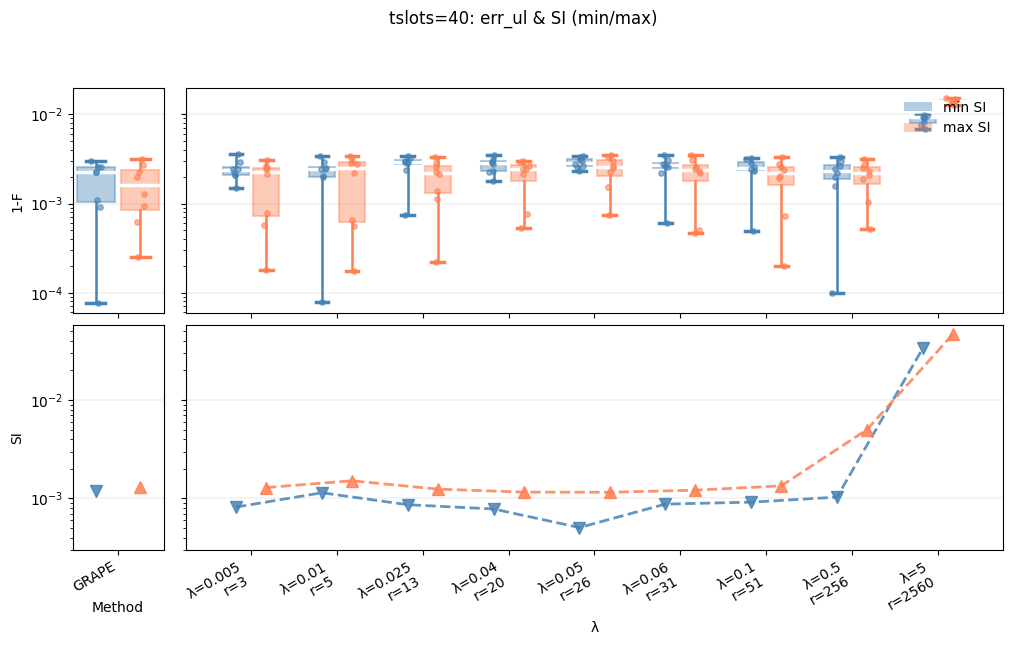

In [11]:
plot_lambda_scan(data_dir_dummyless, lambdas=lam40_dummyless, tslots=40,
                 si_case=['min','max'], log_y=True, separate_si=True,
                 ref_methods=['GRAPE'], detuning=0.0, drive_error=0.0)

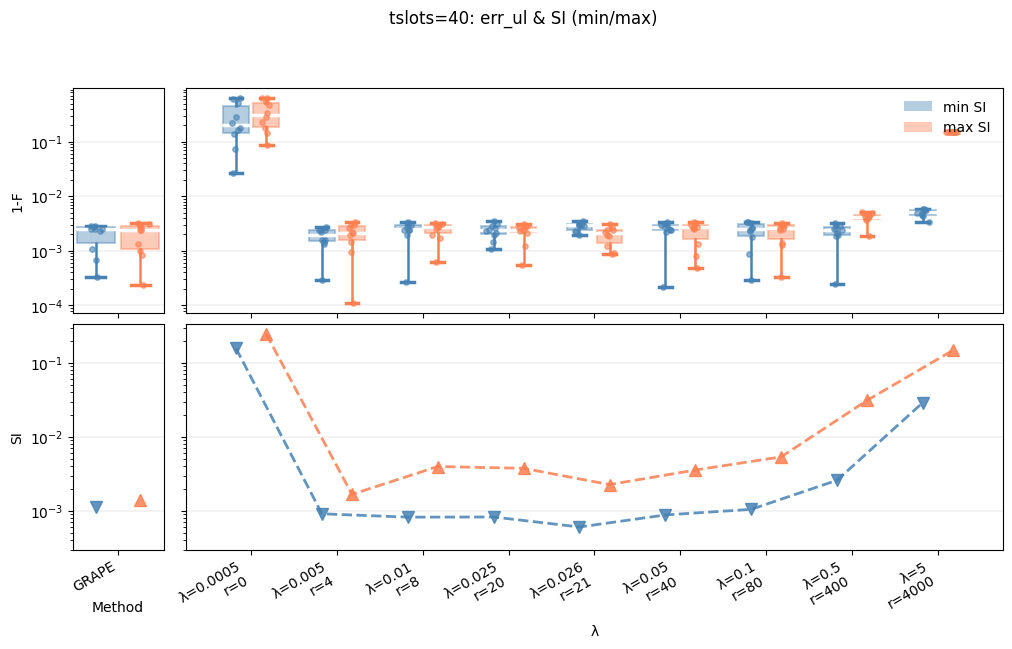

In [12]:
plot_lambda_scan(data_dir_dummyyes, lambdas=lam40_dummyyes, tslots=40,
                 si_case=['min','max'], log_y=True, separate_si=True, ref_methods=['GRAPE'], n_states=10)

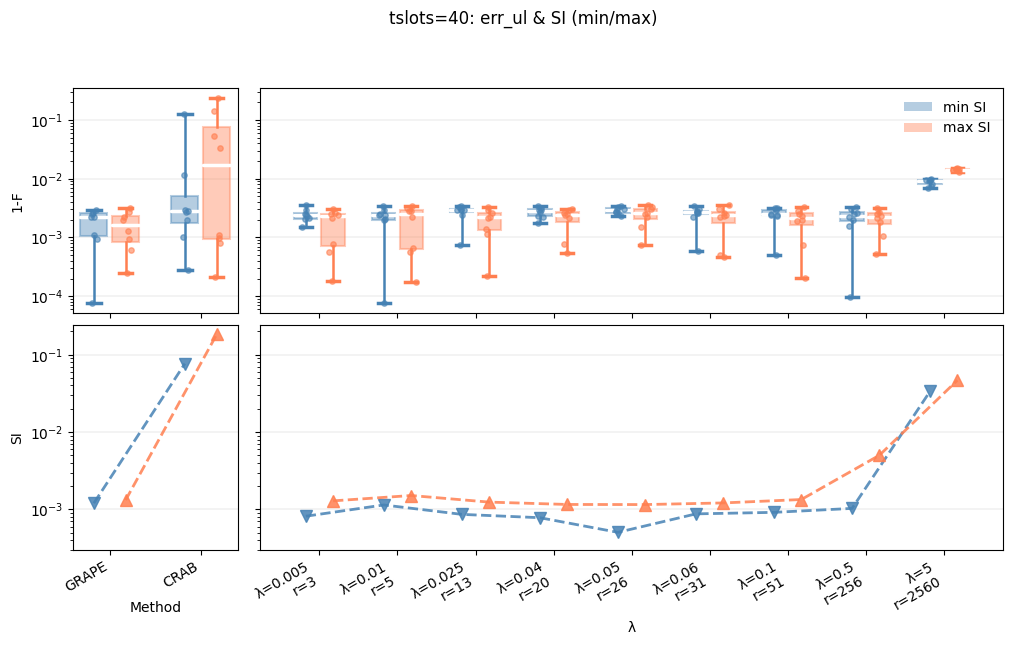

In [13]:
plot_lambda_scan(data_dir_dummyless, lambdas=lam40_dummyless, tslots=40,
                 si_case=['min','max'], log_y=True, separate_si=True, ref_methods=['GRAPE','CRAB'], n_states=8)

# Robustness heatmap

In [14]:
def plot_robustness_heatmap(
    data_dir,
    detunings,
    drive_errors,
    tslots,
    lam,
    si_case="min",
    show="si",
    methods=None,
    omega_drift=10e6,
):
    if methods is None:
        methods = ['GRAPE_AVG', 'GRAPE']

    n_det = len(detunings)
    n_err = len(drive_errors)
    n_methods = len(methods)

    # Gridspec: method panels + colorbar on the right
    width_ratios = [1] * n_methods + [0.05]

    fig, all_axes = plt.subplots(1, n_methods + 1,
                                  figsize=(4 * n_methods + 1, max(4, n_det * 1.0)),
                                  gridspec_kw={'width_ratios': width_ratios, 'wspace': 0.3})
    if n_methods + 1 == 2:
        all_axes = list(all_axes)

    data_axes = list(all_axes[:n_methods])
    cbar_ax = all_axes[-1]

    # Global min/max for shared color scale
    global_vals = []
    grids = []
    std_grids = []

    for m_idx, method in enumerate(methods):
        grid = np.full((n_det, n_err), np.nan)
        std_grid = np.full((n_det, n_err), np.nan)
        for i, det in enumerate(detunings):
            for j, err in enumerate(drive_errors):
                if method == 'GRAPE_AVG':
                    runs = collect_files(data_dir, method=method, num_tslots=tslots,
                                         lam=lam, detuning=det, drive_error=err)
                else:
                    runs = collect_files(data_dir, method=method, num_tslots=tslots,
                                         detuning=det, drive_error=err)
                if not runs:
                    continue
                results = [PulseResult.load(r['path']) for r in runs]
                si_vals = np.array([res.si for res in results])
                best_idx = np.argmin(si_vals) if si_case == "min" else np.argmax(si_vals)
                if show == 'si':
                    grid[i, j] = si_vals[best_idx]
                elif show == 'fid':
                    grid[i, j] = np.mean(results[best_idx].err_ul_list)
                    std_grid[i, j] = np.std(results[best_idx].err_ul_list)
        grids.append(grid)
        std_grids.append(std_grid)
        valid = grid[~np.isnan(grid) & (grid > 0)]
        if len(valid):
            global_vals.extend(valid)

    vmin = min(global_vals) if global_vals else 1e-6
    vmax = max(global_vals) if global_vals else 1

    for m_idx, (method, grid, std_grid) in enumerate(zip(methods, grids, std_grids)):
        ax = data_axes[m_idx]
        im = ax.imshow(grid, aspect='auto', cmap='viridis',
                        norm=LogNorm(vmin=vmin, vmax=vmax))

        for i in range(n_det):
            for j in range(n_err):
                if np.isnan(grid[i, j]):
                    ax.text(j, i, "—", ha='center', va='center', color='#999', fontsize=11)
                else:
                    val = grid[i, j]
                    norm_val = (np.log10(val) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin) + 1e-12)
                    color = 'white' if norm_val < 0.5 else 'black'
                    if show == 'fid' and not np.isnan(std_grid[i, j]):
                        txt = f"{val:.2e}\n±{std_grid[i, j]:.2e}"
                    else:
                        txt = f"{val:.2e}"
                    ax.text(j, i, txt, ha='center', va='center',
                            color=color, fontsize=8, fontweight='bold')

        ax.set_xticks(range(n_err))
        ax.set_xticklabels([f"{e * 100:.0f}%" for e in drive_errors])
        ax.set_xlabel("Drive error")
        ax.set_title(f"{method}", fontsize=12, fontweight='bold')

        if m_idx == 0:
            ax.set_yticks(range(n_det))
            det_labels = []
            for d in detunings:
                freq_hz = d * omega_drift
                if freq_hz == 0:
                    det_labels.append("0")
                elif freq_hz >= 1e6:
                    det_labels.append(f"{freq_hz / 1e6:.1f} MHz")
                elif freq_hz >= 1e3:
                    det_labels.append(f"{freq_hz / 1e3:.0f} kHz")
                else:
                    det_labels.append(f"{freq_hz:.0f} Hz")
            ax.set_yticklabels(det_labels)
            ax.set_ylabel("Detuning")
        else:
            ax.tick_params(labelleft=False)

    # Colorbar on the right
    label = "SI" if show == 'si' else "Mean 1-F"
    fig.colorbar(im, cax=cbar_ax, label=label)

    fig.suptitle(f"Robustness: {label} ({si_case} sample), tslots={tslots}, λ={lam:.2g}",
                 fontsize=13)
    plt.show()

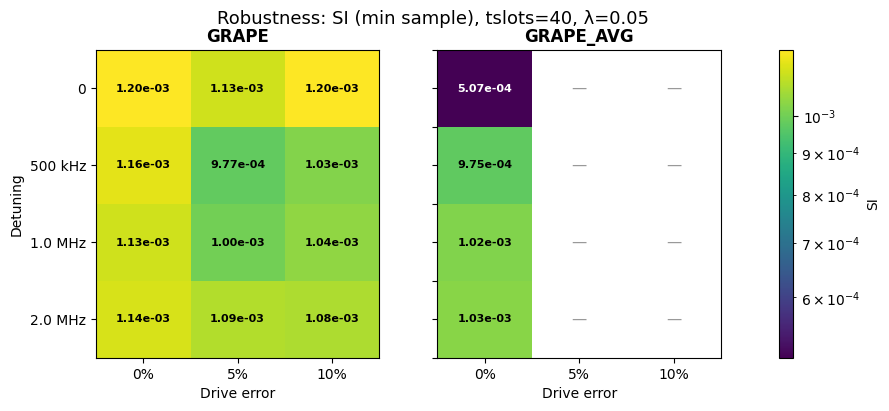

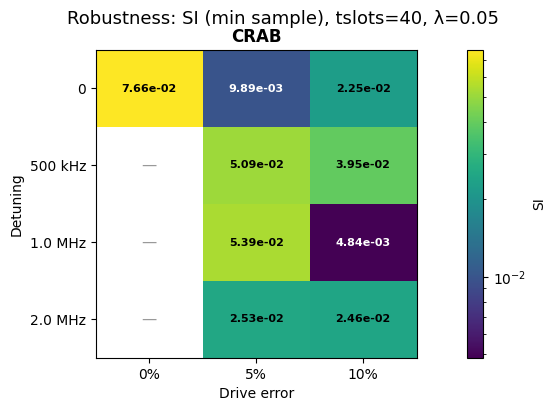

In [25]:
# Robustness heatmap — side by side GRAPE vs GRAPE_AVG
plot_robustness_heatmap(data_dir_dummyless, detunings=[0.0, 0.05, 0.10, 0.2], 
                        drive_errors=[0.0, 0.05, 0.10],
                        tslots=40, lam=0.05, si_case='min', show='si', methods=['GRAPE', 'GRAPE_AVG'])

# Show fidelity instead
plot_robustness_heatmap(data_dir_dummyless, detunings=[0.0, 0.05, 0.10, 0.2],
                        drive_errors=[0.0, 0.05, 0.10],
                        tslots=40, lam=0.05, si_case='min', show='si', methods=['CRAB'])

In [16]:
sum10=summary_lambda(40, data_dir_dummyyes,np.sort([5,0.5,0.05,0.01,0.025,0.005,0.0005]))

In [17]:
np.median(sum10[0.01]['si'])

np.float64(0.0012286152548761785)

In [18]:
np.median(sum10[0.025]['si'])

np.float64(0.0009981911801466973)

In [19]:
5,0.5,0.025,0.005,0.0005

(5, 0.5, 0.025, 0.005, 0.0005)

In [20]:
lam_from_ratio(21,8)

0.041015625

In [21]:
ratio_from_lam?

Signature: ratio_from_lam(lam, n=1)
Docstring:
Return ration lambda/alpha, which intuitively identify the sensitivity/rate for s.i vs fidelity in grape_avg
    f = 0.5n^-3 fHS + lam fSI
    n=1, GRAPE
    n=8,10, for GRAPE AVG
Returns ratio x, which means f_si is x times more influental than the fidelity.
Thus, ratio >> 1 means si first, then fidelity
File:      ~/VeriPulse/src/veripulse/pulse.py
Type:      function